<a href="https://colab.research.google.com/github/celinadeliz/projeto-analise-dados-sctech/blob/main/Desafio_SCTECH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# --- ETAPA 1: Importação e  compreensão dos dados ---

import pandas as pd                 # Importação da Biblioteca Pandas para manipulação e leitura de dados
import matplotlib.pyplot as plt     # Importação da Biblioteca Matplotlib para geração de gráficos
import seaborn as sns               # Importação da Biblioteca Seaborn para visualizações estatísticas

In [3]:
# Carregar o dataset
url = 'https://github.com/celinadeliz/projeto-analise-dados-sctech/raw/refs/heads/main/Sample%20-%20Superstore.csv'
df = pd.read_csv(url, encoding='latin1')

In [4]:
# Visualização inicial da estrutura
print("Informações gerais:")                  # Exibe um título simples para organizar a saída
df.info()                                     # Mostra o total de linhas, se existem valores nulos e quanto de memória ocupa o arquivo
print("\nPrimeiras linhas do dataset:")
display(df.head())                            # Mostra as 5 primeiras linhas
print("\nTipos de cada coluna:")
display(df.dtypes)                            # Lista o formato de cada coluna
print("\nDescrição:")
df.describe()                                 # Faz um resumo matemático das colunas numéricas


Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   f

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164



Tipos de cada coluna:


,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object



Descrição:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
# --- ETAPA 2: Tratamento e preparação dos dados ---

print("Valores nulos por coluna:\n", df.isnull().sum())   # Verificação de valores nulos

Valores nulos por coluna:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [6]:
# Verificação de duplicados

duplicados = df.duplicated().sum()                      # Procura por linhas que são iguais e soma a quantidade de vezes que encontra a repetição
print(f"\nTotal de linhas duplicadas: {duplicados}")    # Mostra a contagem de linhas duplicadas
if duplicados >0:                                       # Se houver linhas duplicadas, remova
  df.drop_druplicates(inplace=True)


Total de linhas duplicadas: 0


In [7]:
# Conversão de tipos: Datas

df['Order Date'] = pd.to_datetime(df['Order Date'])     # Converte a coluna 'Order Date' de texto (object) para o formato real de data (datetime)
df['Ship Date'] = pd.to_datetime(df['Ship Date'])       # Faz a mesma conversão para a coluna 'Ship Date', permitindo cálculos de tempo entre elas

print("\nTratamento concluído com sucesso")


Tratamento concluído com sucesso


In [8]:
# Conversão de tipos: valores numéricos

# Garante que as colunas principais são números

df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

In [9]:
# Organização e padronização das colunas

df.columns = df.columns.str.strip()
print("Colunas padronizadas!")

Colunas padronizadas!


In [10]:
# Identificação e tratamento de possíveis outliers

print("Maior venda registrada:", df['Sales'].max())           # Busca o valor máximo de vendas para conferir se algo está fora do padrão

print("Maior lucro registrado:", df['Profit'].max())          # Identifica o maior lucro para ver o teto de rentabilidade da loja

print("Maior Prejuízo (Menor Lucro):", df['Profit'].min())    # Encontra o maior prejuízo para detectar possíveis falhas de operação ou erros

df = df[df['Sales'] < 20000]                                  # Remove do dataset qualquer venda acima de 20.000 para "limpar" os valores extremos

Maior venda registrada: 22638.48
Maior lucro registrado: 8399.976
Maior Prejuízo (Menor Lucro): -6599.978


In [11]:
# --- ETAPA 3: Análise exploratória ---

# Filtros

vendas_prejuizo = df[df['Profit'] < 0]                                  # Ver apenas as vendas que deram prejuízo

piores_prejuizos = vendas_prejuizo.sort_values(by='Profit').head(10)    # Ordenando o prejuízo para ver os casos mais críticos

print("\nTop 10 maiores prejuízos identificados (Filtro):")
print(piores_prejuizos[['Customer Name', 'Category', 'Profit']])



Top 10 maiores prejuízos identificados (Filtro):
         Customer Name         Category     Profit
7772     Cindy Stewart       Technology -6599.9780
683     Grant Thornton       Technology -3839.9904
9774       Luke Foster  Office Supplies -3701.8928
3011    Sharelle Roach       Technology -3399.9800
4991     Henry Goldwyn  Office Supplies -2929.4845
3151  Natalie Fritzler       Technology -2639.9912
5310       Nathan Cano  Office Supplies -2287.7820
9639       Joseph Holt        Furniture -1862.3124
1199  Zuschuss Carroll  Office Supplies -1850.9464
27     Tracy Blumstein        Furniture -1665.0522


In [12]:
# Agrupamento

vendas_regiao = df.groupby('Region')['Sales'].sum()         # Qual Região vende mais?

lucro_segmento = df.groupby('Segment')['Profit'].sum()      # Qual o lucro por Segmento de cliente?

print("\nRegião que mais vende: ")
print(vendas_regiao)

print("\nLucro por Segmento: ")
print(lucro_segmento)


Região que mais vende: 
Region
Central    501239.8908
East       678781.2400
South      369083.4250
West       725457.8245
Name: Sales, dtype: float64

Lucro por Segmento: 
Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     62109.7569
Name: Profit, dtype: float64


In [13]:
# Ordenação

vendas_regiao_ordenada = vendas_regiao.sort_values(ascending=False)   # Ordenando as vendas por região do maior para o menor

print("\nRegiões ordenadas por volume de vendas:")
print(vendas_regiao_ordenada)


Regiões ordenadas por volume de vendas:
Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      369083.4250
Name: Sales, dtype: float64


In [14]:
# Análise das Variáveis Relevantes: Categoria

vendas_categoria = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)   # Agrupando para ver o total de vendas por Categoria de produto

lucro_categoria = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)   # Agrupando para ver o total de lucro por Categoria de produto

print("Volume de Vendas por Categoria:")
print(vendas_categoria)

print("\nTotal de Lucro por Categoria:")
print(lucro_categoria)

Volume de Vendas por Categoria:
Category
Technology         813515.5530
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Total de Lucro por Categoria:
Category
Technology         147266.0265
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [15]:
# Investigação de Relações: Desconto vs Lucro

relacao_desconto = df.groupby('Discount')['Profit'].mean()                        # Agrupamento por nível de desconto para ver onde o lucro começa a cair

vendas_regiao = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)  # Análise por Região

# Análise de Tendência Temporal

df['Month_Year'] = df['Order Date'].dt.to_period('M')                             # Coluna de Mes/Ano para ver a evolução das vendas
tendencia_vendas = df.groupby('Month_Year')['Sales'].sum()

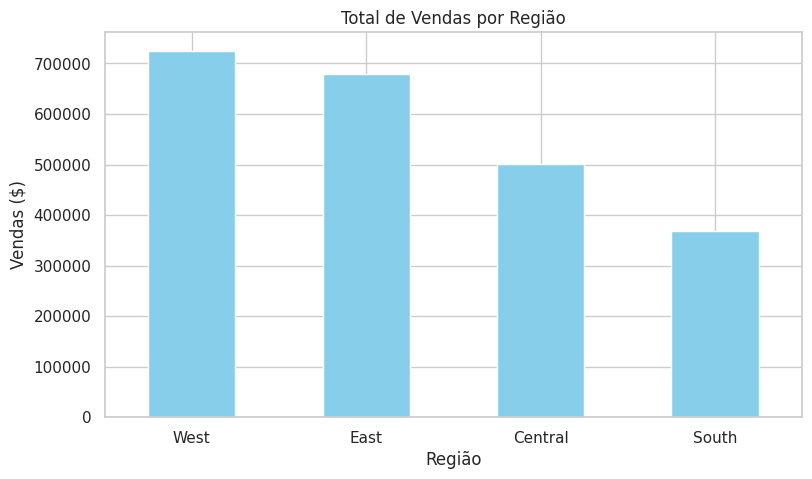


------------



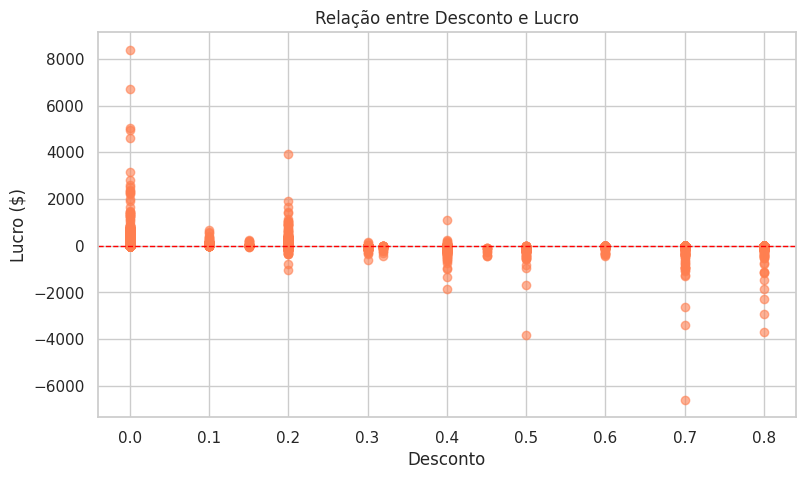

In [16]:
# Geração de visualizações gráficas para apoiar a interpretação dos dados

# Estilo para os gráficos
sns.set_theme(style="whitegrid")

# 1. Gráfico de Barras: Vendas por Região
plt.figure(figsize=(9, 5))
vendas_regiao.plot(kind='bar', color='skyblue')
plt.title('Total de Vendas por Região')
plt.xlabel('Região')
plt.ylabel('Vendas ($)')
plt.xticks(rotation=0)                 # Deixa os nomes das regiões retos para facilitar a leitura
plt.show()

print("\n------------\n")

# 2. Gráfico de Dispersão: Relação entre Desconto e Lucro
plt.figure(figsize=(9, 5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.6, color='coral')
plt.title('Relação entre Desconto e Lucro')
plt.xlabel('Desconto')
plt.ylabel('Lucro ($)')
plt.axhline(0, color='red', linestyle='--', linewidth=1) # Linha vermelha no zero para destacar o prejuízo
plt.show()

In [17]:
# Salva o dataset tratado em um novo arquivo CSV
df.to_csv('Sample_Superstore_Limpo.csv', index=False)